# Satellite Image Classification using CNN

#### Import necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from glob import glob
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

#### Fetch the data using glob

##### The data contains 4 subclasses. Store all 4 in different variables

In [2]:
cloudy = glob('satellite_data/cloudy/*.jpg')
desert = glob('satellite_data/desert/*.jpg')
green_area = glob('satellite_data/green_area/*.jpg')
water = glob('satellite_data/water/*.jpg')

#### Find the number of images of all classes

In [3]:
print("Number of images in each classes are\nCloudy:",len(cloudy),"\nDesert:",len(desert),"\nGreen Area:",len(green_area),"\nWater:",len(water))

Number of images in each classes are
Cloudy: 1500 
Desert: 1131 
Green Area: 1500 
Water: 1500


#### Store all the images inside a list and create a list with the corresponding labels

In [4]:
image = []
label = []

for i in cloudy:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in desert:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

for i in green_area:
    img = plt.imread(i)
    image.append(img)
    label.append(2)

for i in water:
    img = plt.imread(i)
    image.append(img)
    label.append(3)

#### Shuffle both image list and label list using shuffle function from sklearn utils

In [5]:
image, label = shuffle(image, label, random_state = 100)

#### Plot a few images from our shuffled list with its corresponding label

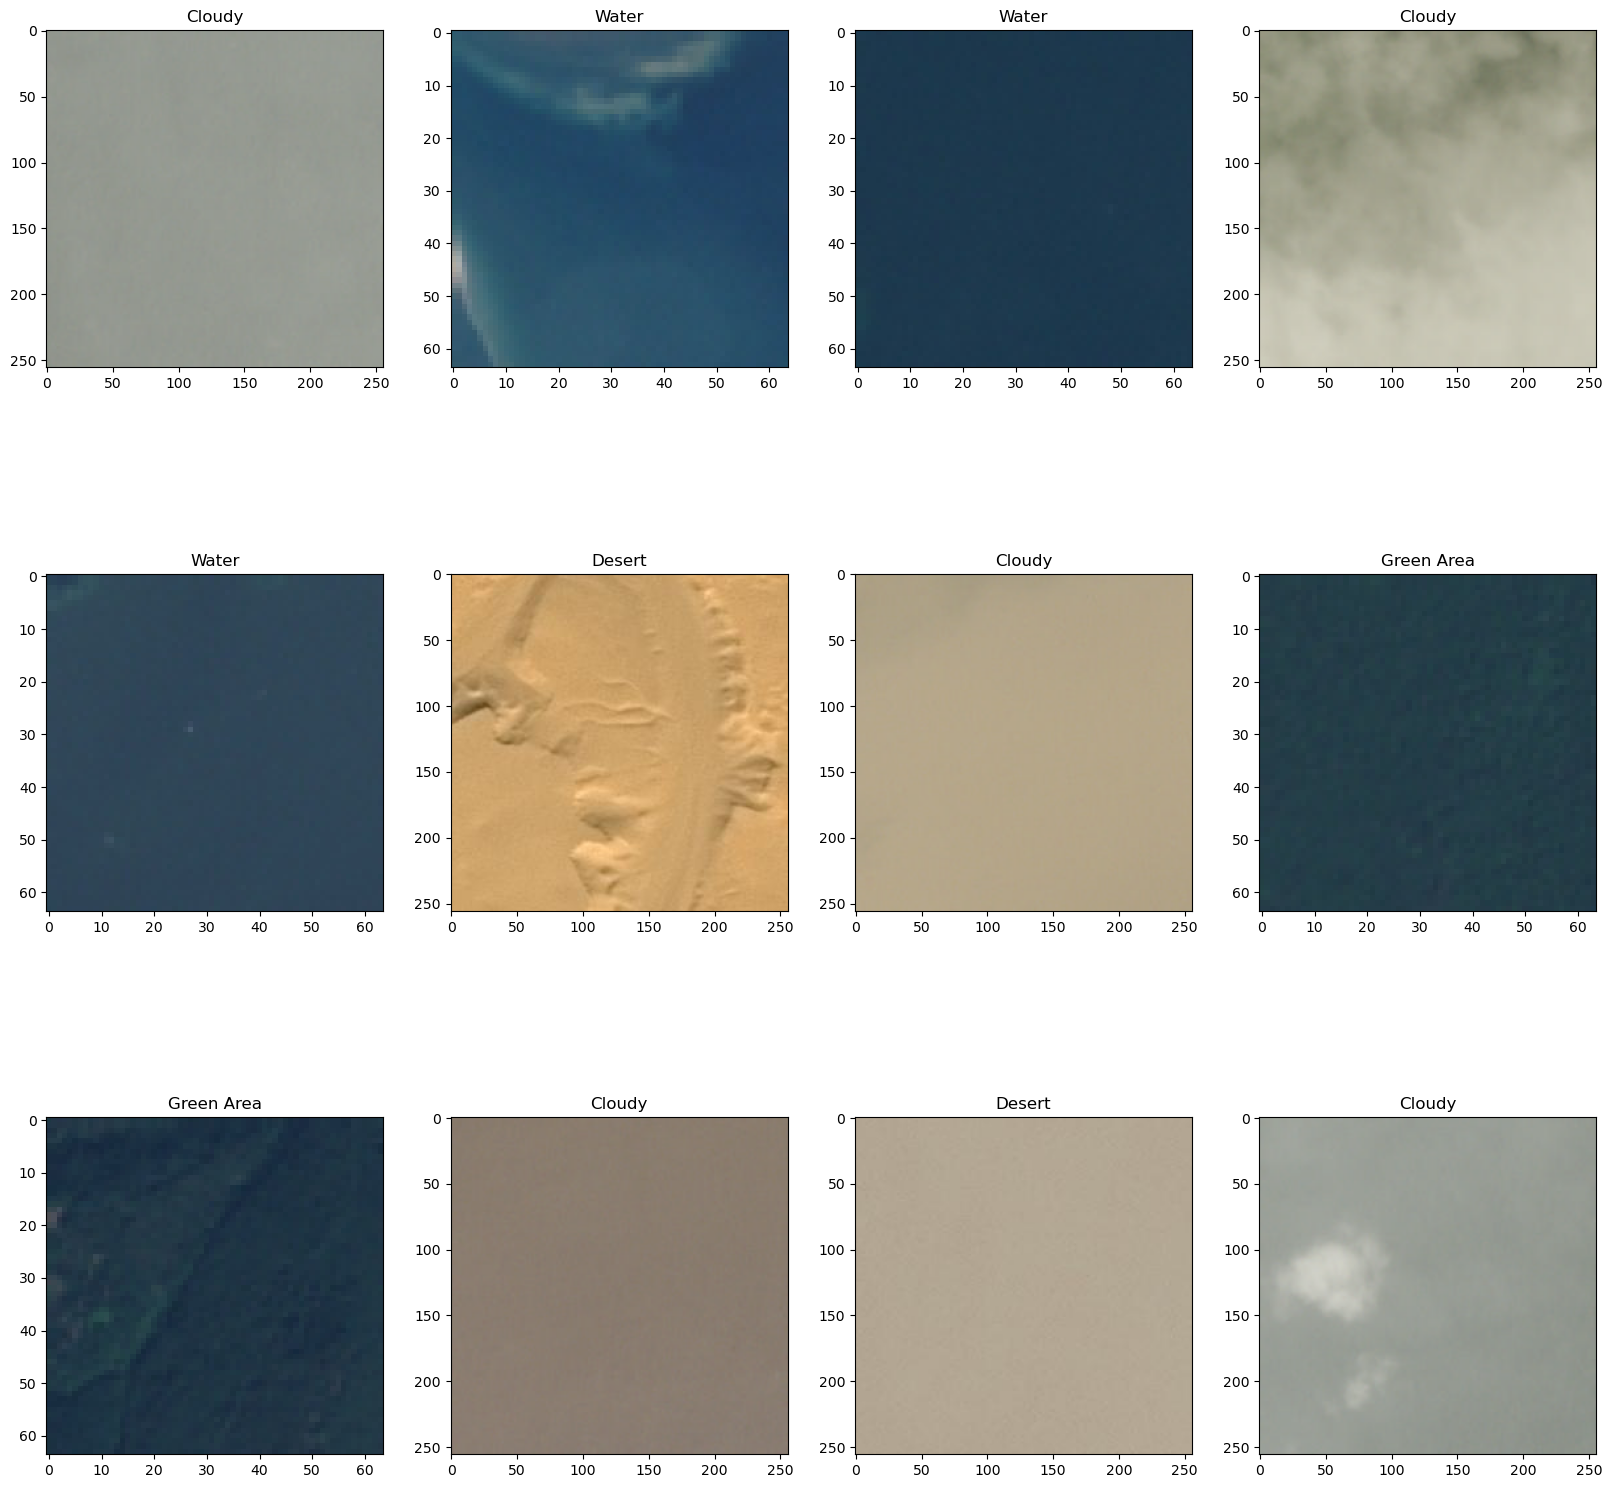

In [6]:
plt.figure(figsize = (20,20))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 0:
        plt.title("Cloudy")
    elif label[i] == 1:
        plt.title("Desert")
    elif label[i] == 2:
        plt.title("Green Area")
    else:
        plt.title("Water")

#### Check the shape of the first 10 images in our list 

In [7]:
for i in range(10):
    print(image[i].shape)

(256, 256, 4)
(64, 64, 3)
(64, 64, 3)
(256, 256, 4)
(64, 64, 3)
(256, 256, 3)
(256, 256, 4)
(64, 64, 3)
(64, 64, 3)
(256, 256, 4)


#### Reshape the images to 128x128
#### Also reassign them to new variable named x and convert them to a numpy array

In [8]:
x = []

for i in image:
    x.append(resize(i,(128,128,3)))

x = np.array(x)

#### Create numpy array named y from our training and testing label lists we created earlier

In [9]:
y = np.array(label)

#### Split the data into training and testing set

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

#### Plot some of our reshaped images

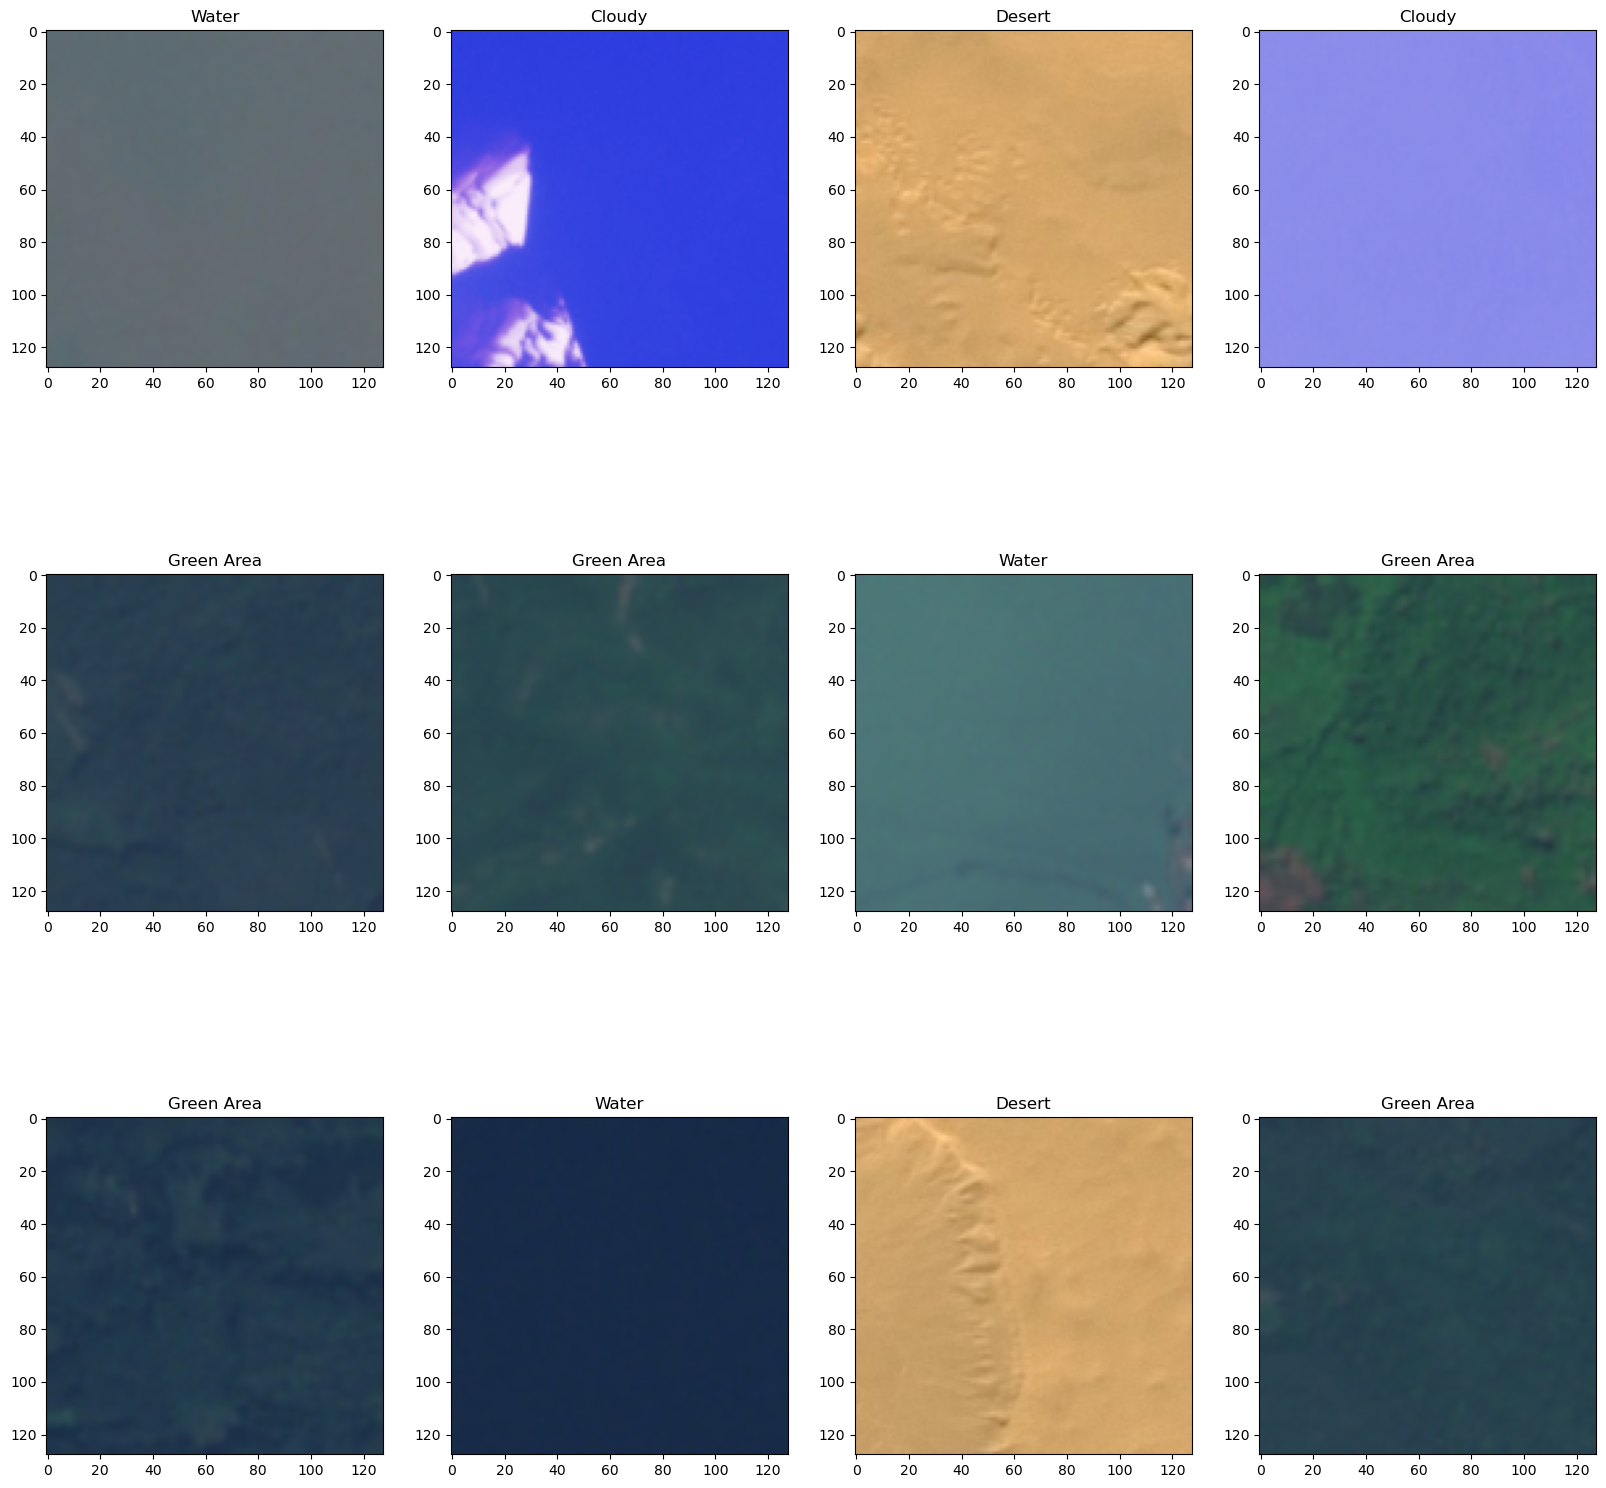

In [11]:
plt.figure(figsize = (20,20))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i])
    if y_train[i] == 0:
        plt.title("Cloudy")
    elif y_train[i] == 1:
        plt.title("Desert")
    elif y_train[i] == 2:
        plt.title("Green Area")
    else:
        plt.title("Water")

#### Check the shape of x_train and x_test and y_train and y_test

In [12]:
print("Shape of x_train is: ",x_train.shape)
print("Shape of x_test is: ",x_test.shape)
print("Shape of y_train is: ",y_train.shape)
print("Shape of y_test is: ",y_test.shape)

Shape of x_train is:  (4504, 128, 128, 3)
Shape of x_test is:  (1127, 128, 128, 3)
Shape of y_train is:  (4504,)
Shape of y_test is:  (1127,)


#### Create a keras Sequential model with convolution layers, Flatten and  Hidden layers

In [13]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,(3,3), activation = "relu", input_shape = (128,128,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(32,(3,3), activation = "relu"),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation = "relu"),
    keras.layers.Dense(4, activation = "softmax")
    
])

#### Compile our model

In [14]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

#### Check model summary

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,686,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,692,132 (14.08 MB)

 Trainable params: 3,692,132 (14.08 MB)

 Non-trainable params: 0 (0.00 B)

#### Train our model with x_train and y_train

In [16]:
model.fit(x_train, y_train, epochs = 25, batch_size = 32, validation_split = 0.01)

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.8461 - loss: 0.3271 - val_accuracy: 0.9348 - val_loss: 0.1963
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9118 - loss: 0.2069 - val_accuracy: 0.9565 - val_loss: 0.2183
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9121 - loss: 0.1991 - val_accuracy: 0.8696 - val_loss: 0.2533
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9284 - loss: 0.1624 - val_accuracy: 0.9565 - val_loss: 0.1443
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.9264 - loss: 0.1710 - val_accuracy: 0.9565 - val_loss: 0.1515
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9302 - loss: 0.1505 - val_accuracy: 0.8478 - val_loss: 0.3222
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9305 - loss: 0.1619 - val_accuracy: 0.9565 - val_loss: 0.1341
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.9244 - loss: 0.1621 -

#### Evaluate our model

In [17]:
model.evaluate(x_train,y_train)

141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9516 - loss: 0.1087


[0.10874050855636597, 0.951598584651947]

#### Make predictions with x_test

In [18]:
prediction = model.predict(x_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


#### Use np.argmax to fetch indices of max element of the array and store the values in a list

In [19]:
y_pred = [int(np.argmax(i)) for i in prediction]

In [20]:
y_pred[:5]

[2, 0, 1, 0, 2]

#### Plot x_test along with label from our prediction

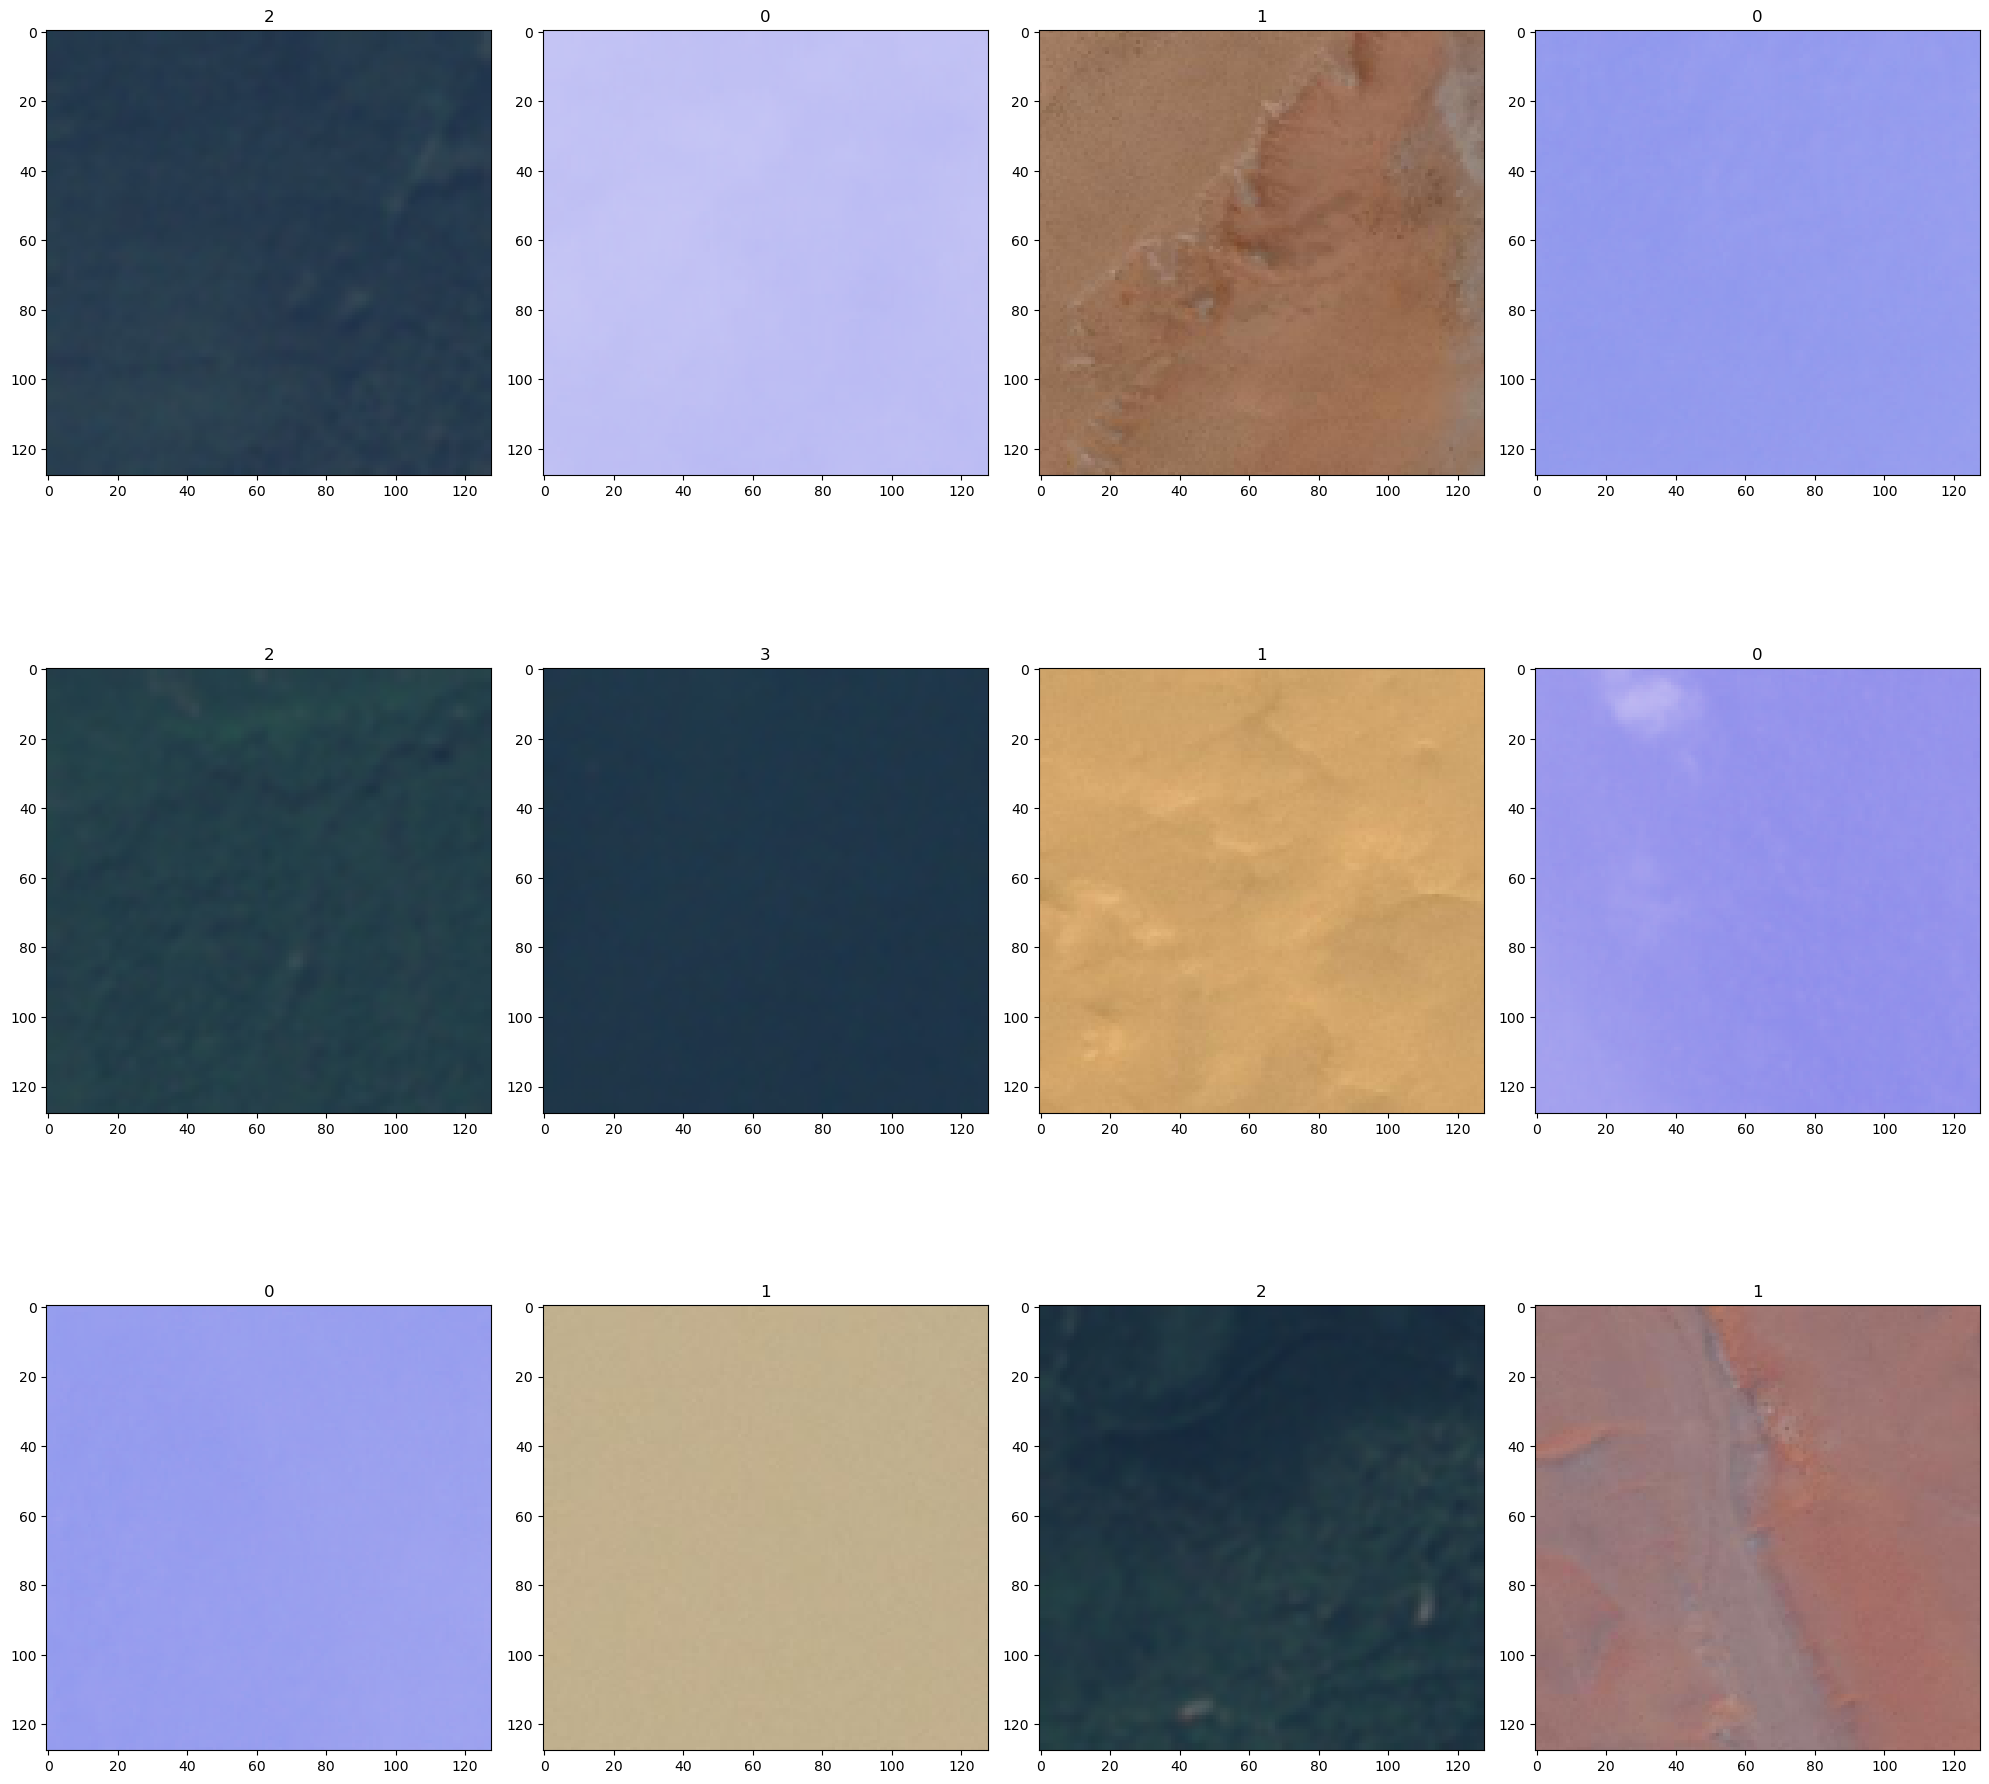

In [21]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i])
    plt.title(y_pred[i])
plt.tight_layout()
plt.show()

#### Plot confusion matrix on a heatmap

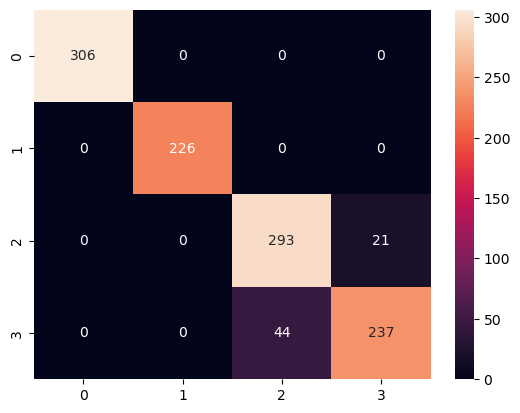

In [22]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt = "d")
plt.show()

#### Classification report

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       226
           2       0.87      0.93      0.90       314
           3       0.92      0.84      0.88       281

    accuracy                           0.94      1127
   macro avg       0.95      0.94      0.94      1127
weighted avg       0.94      0.94      0.94      1127



***